In [38]:
import sys
import os

# Get the directory of the current notebook
current_dir = os.path.dirname(os.path.abspath('__file__'))

# Move up to the root directory
root_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the root directory to the sys.path
sys.path.append(root_dir)

from graph_gen.gen_graph import gen_graph
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain import hub
from langchain_openai.chat_models import ChatOpenAI
from langchain.agents import create_openai_functions_agent
from langgraph.prebuilt.tool_executor import ToolExecutor
from typing import Annotated, Dict, List, Optional, TypedDict, Tuple, Sequence, Union, Literal
from langchain_core.messages import AIMessage, BaseMessage, FunctionMessage, HumanMessage, ToolMessage
from langgraph.graph import END, StateGraph, MessageGraph
from langchain_core.agents import AgentAction, AgentFinish
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain.output_parsers.openai_tools import (
    JsonOutputToolsParser,
    PydanticToolsParser
)
from langchain.agents.output_parsers.openai_functions import OpenAIFunctionsAgentOutputParser
import operator
import re

### [LangGraph: Chat Agent Executor](https://www.youtube.com/watch?v=Un-88uJKdiU&list=PLfaIDFEXuae16n2TWUkKq5PgJ0w6Pkwtg&index=3) <img src="https://upload.wikimedia.org/wikipedia/commons/4/42/YouTube_icon_%282013-2017%29.png" alt="YouTube" width="20" height="20">

In [39]:
# Graph   
graph_spec = """

call_model(AgentState)
    has_function_call => call_tool

call_tool
    => call_model

"""

# Conditional edges
def has_function_call(state):
    last_message = state["messages"][-1]
    return "function_call" in last_message.additional_kwargs

In [40]:
# State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    intermediate_steps: Annotated[Sequence[BaseMessage], operator.add]

In [41]:
# Tools
tools = [TavilySearchResults(max_results=1)]
functions = [convert_to_openai_function(tool) for tool in tools]
model = ChatOpenAI(model="gpt-4o", temperature=0, streaming=True)
model = model.bind_functions(functions)
tool_executor = ToolExecutor(tools)

def print_result(s):
    if 'agent' in s and 'agent_outcome' in s['agent'] and isinstance(s['agent']['agent_outcome'], AgentFinish):
        print(s['agent']['agent_outcome'].return_values['output'])
    else:
        print(s)
    print()

In [42]:
# Nodes
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    return { "messages": [response] }

def call_tool(state):
    messages = state["messages"]
    last_message = messages[-1]
    action = ToolInvocation(
        tool=last_message.additional_kwargs["function_call"]["name"],
        tool_input=json.loads(last_message.additional_kwargs["function_call"]["arguments"])
    )
    response = tool_executor.invoke(action)
    function_message = FunctionMessage(content=str(response), name=action.tool)
    return { "intermediate_steps": [function_message] }

In [43]:
# Run the graph
# - generate the python langgraph code
# - execute the code, runnable graph in variable 'app'
# - test the graph
graph_code = gen_graph("chat_agent_executor", graph_spec)
exec(graph_code)

# 'graph' contains the compiled graph
inputs = { "messages": [HumanMessage(content="who is a famous voice actress from the 50s")], "intermediate_steps": [] }
for s in chat_agent_executor.stream(inputs):
    print_result(s)

{'call_model': {'messages': [AIMessage(content='One of the most famous voice actresses from the 1950s is June Foray. She is best known for her work in animated television shows and films. Some of her most iconic roles include the voice of Rocky the Flying Squirrel and Natasha Fatale in "The Rocky and Bullwinkle Show," as well as Granny in the "Looney Tunes" series. June Foray\'s extensive career and versatile voice acting made her a legendary figure in the animation industry.', response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3aa7262c27'}, id='run-4b4354d6-f740-4e17-8526-8aaace63b01e-0')]}}



In [44]:
print(graph_code)

chat_agent_executor = StateGraph(AgentState)
chat_agent_executor.add_node('call_model', call_model)
chat_agent_executor.add_node('call_tool', call_tool)

chat_agent_executor.set_entry_point('call_model')

def after_call_model(state: AgentState):
    if has_function_call(state):
        return 'call_tool'
    return END

call_model_dict = {'call_tool': 'call_tool', END: END}
chat_agent_executor.add_conditional_edges('call_model', after_call_model, call_model_dict)

chat_agent_executor.add_edge('call_tool', 'call_model')

chat_agent_executor = chat_agent_executor.compile()


In [45]:
messages = [HumanMessage(content="who invented tonal?")]
for s in chat_agent_executor.stream({"messages": messages, "intermediate_steps": []}):
    print(s)
    if 'call_model' in s and 'messages' in s['call_model']:
        message = s['call_model']['messages'][-1]
        print(f"\n{message.content}") if message.content else print(message.additional_kwargs)

{'call_model': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'arguments': '{"query":"who invented Tonal"}', 'name': 'tavily_search_results_json'}}, response_metadata={'finish_reason': 'function_call', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3aa7262c27'}, id='run-de1d3c26-3cd7-40c1-b07d-862dc29bfba7-0')]}}
{'function_call': {'arguments': '{"query":"who invented Tonal"}', 'name': 'tavily_search_results_json'}}
{'call_tool': {'intermediate_steps': [FunctionMessage(content='[{\'url\': \'https://www.businessinsider.com/tonal-review-home-fitness-startup-2019-11?op=1\', \'content\': "Tonal was invented by Aly Orady, a Hewlett-Packard veteran who wanted an easier way to stay in shape at home that didn\'t involve sweaty, used equipment and tedious trips to the gym."}]', name='tavily_search_results_json')]}}
{'call_model': {'messages': [AIMessage(content='Tonal was invented by Aly Orady. He founded the company in 2015 with the aim of creating a mor

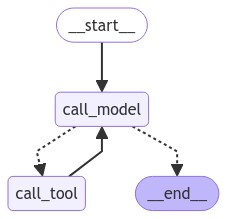

In [46]:
from IPython.display import Image, display

try:
    display(Image(chat_agent_executor.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### 